## Total Fuel Evaluation (Sum of Physics Phase Models)

This notebook evaluates total fuel consumption by summing the phase-level XGBoost physics predictions.

Expected inputs are the five physics phase prediction CSV files from the phase notebooks:
- `pred_physics_takeoff.csv`
- `pred_physics_climb.csv`
- `pred_physics_cruise.csv`
- `pred_physics_descent.csv`
- `pred_physics_landing.csv`


Each phase CSV should contain every November-December test flight. Phase predictions are `0` only when that phase is absent or invalid for that flight.



### Load truth and phase predictions


In [ ]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../../data.sqlite"
FEATURE_TABLE = "flight_phase_features_physics"
YEAR = 2022
CSV_DIR = "csv_files"

PHASES = ["takeoff", "climb", "cruise", "descent", "landing"]
PHASE_FUEL_COLS = [f"{phase}_fuel" for phase in PHASES]
PHASE_PRED_COLS = [f"pred_physics_{phase}" for phase in PHASES]


def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.rsplit("-", n=4, expand=True)
    if parts.shape[1] != 5:
        raise ValueError("flight_id must end with: mm-dd-hh-mm")

    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {
            "year": year,
            "month": pd.to_numeric(parts[1], errors="coerce"),
            "day": pd.to_numeric(parts[2], errors="coerce"),
            "hour": pd.to_numeric(parts[3], errors="coerce"),
            "minute": pd.to_numeric(parts[4], errors="coerce"),
        },
        errors="coerce",
    )
    return out


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-6, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11, 12])].copy()

if "total_fuel_modeled" in test.columns:
    test["true_total"] = test["total_fuel_modeled"].astype(float)
else:
    test["true_total"] = test[PHASE_FUEL_COLS].fillna(0.0).sum(axis=1)

truth_cols = ["flight_id", "true_total"] + PHASE_FUEL_COLS
truth = test[truth_cols].copy()
truth[PHASE_FUEL_COLS] = truth[PHASE_FUEL_COLS].fillna(0.0)

pred_all = truth.copy()

for phase in PHASES:
    path = os.path.join(CSV_DIR, f"pred_physics_{phase}.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file not found: {path}")

    phase_df = pd.read_csv(path)
    pred_col = f"pred_physics_{phase}"
    required = ["flight_id", pred_col]
    missing_cols = [col for col in required if col not in phase_df.columns]
    if missing_cols:
        raise ValueError(f"{path} is missing columns: {missing_cols}")
    if phase_df["flight_id"].duplicated().any():
        raise ValueError(f"{path} contains duplicate flight_id values")

    pred_all = pred_all.merge(phase_df[["flight_id", pred_col]], on="flight_id", how="left")

missing_predictions = pred_all[PHASE_PRED_COLS].isna().sum()
if missing_predictions.any():
    raise ValueError(
        "Missing physics phase predictions found. Rerun all physics phase notebooks after the export update. "
        f"{missing_predictions[missing_predictions > 0]}"
    )

pred_all[PHASE_PRED_COLS] = pred_all[PHASE_PRED_COLS].fillna(0.0)
pred_all["pred_total"] = pred_all[PHASE_PRED_COLS].sum(axis=1)
pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]
pred_all["abs_err"] = np.abs(pred_all["residual"])

print("Loaded November-December flights:", len(test))
print("Merged prediction rows:", len(pred_all))
print("Missing predictions by phase:")
print(missing_predictions)



Loaded November-December flights: 3505
Merged prediction rows: 3505
Missing predictions by phase:
pred_physics_takeoff    0
pred_physics_climb      0
pred_physics_cruise     0
pred_physics_descent    0
pred_physics_landing    0
dtype: int64


### Total fuel metrics


In [2]:
y_true = pred_all["true_total"].to_numpy(float)
y_pred = pred_all["pred_total"].to_numpy(float)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

y_range = np.max(y_true) - np.min(y_true)
nrmse = np.nan if y_range == 0 else rmse / y_range
nmae = np.nan if y_range == 0 else mae / y_range

mape_val = mape(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", len(pred_all))
print(f"MAPE: {mape_val:.4f}%")
print(f"R²  : {r2:.4f}")
print(f"NRMSE: {nrmse:.4f}")
print(f"NMAE : {nmae:.4f}")


TOTAL RESULTS (sum of phase ML)
N: 3505
MAPE: 4.0045%
R²  : 0.9694
NRMSE: 0.0263
NMAE : 0.0194


### Estimated vs actual total fuel


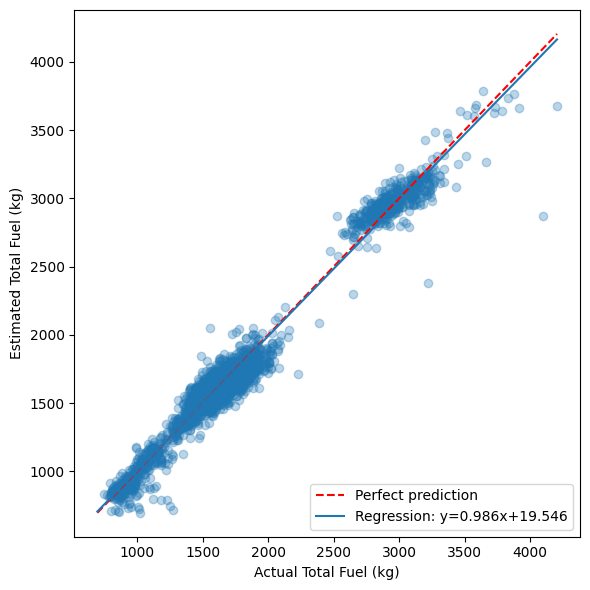

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_all["true_total"], pred_all["pred_total"], alpha=0.3)

min_val = min(pred_all["true_total"].min(), pred_all["pred_total"].min())
max_val = max(pred_all["true_total"].max(), pred_all["pred_total"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

m, b = np.polyfit(pred_all["true_total"], pred_all["pred_total"], 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m * x_line + b, label=f"Regression: y={m:.3f}x+{b:.3f}")

plt.xlabel("Actual Total Fuel (kg)")
plt.ylabel("Estimated Total Fuel (kg)")
plt.legend(loc="lower right")
plt.tight_layout()
out_path = os.path.join("../../outputs", "tot_config2.png")
plt.savefig(out_path, dpi=300)
plt.show()
plt.close


### Average fuel by phase


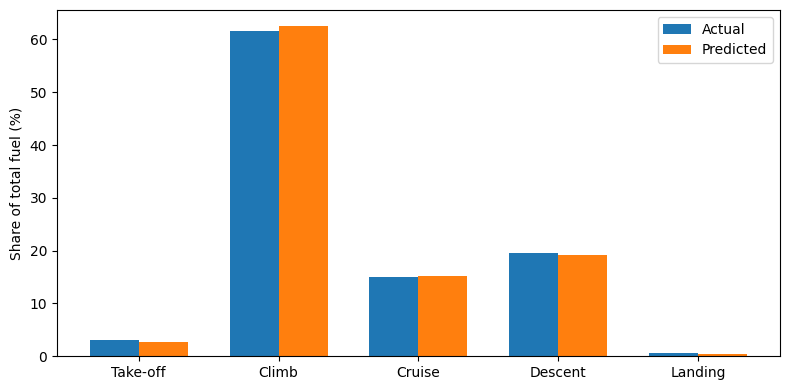

In [4]:
phase_names = {
    "takeoff": "Take-off",
    "climb":   "Climb",
    "cruise":  "Cruise",
    "descent": "Descent",
    "landing": "Landing"
}


phase_compare_share = pd.DataFrame({
    "Phase": [phase_names[phase] for phase in PHASES],
    "Actual": [
        pred_all[f"{phase}_fuel"].sum()
        / sum(pred_all[f"{p}_fuel"].sum() for p in PHASES)
        * 100
        for phase in PHASES
    ],
    "Predicted": [
        pred_all[f"pred_physics_{phase}"].sum()
        / sum(pred_all[f"pred_physics_{p}"].sum() for p in PHASES)
        * 100
        for phase in PHASES
    ],
})

x = np.arange(len(phase_compare_share))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, phase_compare_share["Actual"], width=width, label="Actual")
plt.bar(x + width / 2, phase_compare_share["Predicted"], width=width, label="Predicted")

plt.xticks(x, phase_compare_share["Phase"])
plt.ylabel("Share of total fuel (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("../../outputs", "phase_share_comparison2.png"), dpi=300)
plt.show()



### Route distance and flight counts

Aggregate the November-December test flights by airport pair. Each row gives one route, the route distance, and the number of flights observed for that route.


In [5]:
route_cols = ["flight_id", "estdepartureairport", "estarrivalairport", "great_circle_distance"]

route_data = pred_all[["flight_id"]].merge(
    test[route_cols],
    on="flight_id",
    how="left",
)

route_data["route"] = route_data["estdepartureairport"] + "-" + route_data["estarrivalairport"]

route_summary = (
    route_data
    .dropna(subset=["route", "great_circle_distance"])
    .groupby(["route", "estdepartureairport", "estarrivalairport"], as_index=False)
    .agg(
        distance_m=("great_circle_distance", "mean"),
        n_flights=("flight_id", "count"),
    )
    .sort_values(["n_flights", "route"], ascending=[False, True])
)

route_summary["distance_km"] = route_summary["distance_m"] / 1000
route_summary = route_summary[["route", "estdepartureairport", "estarrivalairport", "distance_km", "n_flights"]]

out_path = os.path.join(CSV_DIR, "route_distance_counts_config2.csv")
route_summary.to_csv(out_path, index=False)

print(f"Saved route summary to {out_path}")


Saved route summary to csv_files/route_distance_counts_config2.csv


### Prepare route-level percentages

Create the route-level percentage table used by the actual-vs-predicted stacked bar plots.


In [6]:
route_phase = pred_all[["flight_id"] + PHASE_FUEL_COLS + PHASE_PRED_COLS].merge(
    route_data[["flight_id", "route"]],
    on="flight_id",
    how="left",
)

route_phase_mean = (
    route_phase
    .dropna(subset=["route"])
    .groupby("route")[PHASE_FUEL_COLS + PHASE_PRED_COLS]
    .mean()
)

actual_total = route_phase_mean[PHASE_FUEL_COLS].sum(axis=1)

# Actual phase shares sum to 100%. Predicted phase shares are scaled by the
# actual total, so the full predicted bar shows over/under-prediction.
actual_percent = route_phase_mean[PHASE_FUEL_COLS].div(actual_total, axis=0) * 100
pred_vs_actual_percent = route_phase_mean[PHASE_PRED_COLS].div(actual_total, axis=0) * 100

actual_percent.columns = [f"actual_pct_{phase}" for phase in PHASES]
pred_vs_actual_percent.columns = [f"pred_vs_actual_pct_{phase}" for phase in PHASES]

route_phase_percent = pd.concat([actual_percent, pred_vs_actual_percent], axis=1).reset_index().merge(
    route_summary[["route", "distance_km", "n_flights"]],
    on="route",
    how="left",
)

route_phase_percent["pred_total_vs_actual_pct"] = route_phase_percent[
    [f"pred_vs_actual_pct_{phase}" for phase in PHASES]
].sum(axis=1)

route_phase_percent = route_phase_percent.sort_values(["n_flights", "route"], ascending=[False, True])

out_path = os.path.join(CSV_DIR, "route_actual_100_predicted_vs_actual_percent_config2.csv")
route_phase_percent.to_csv(out_path, index=False)
print(f"Saved route phase percentages to {out_path}")



Saved route phase percentages to csv_files/route_actual_100_predicted_vs_actual_percent_config2.csv


### Route-level actual vs predicted phase shares

Plot route-level phase composition with actual fuel normalized to 100\%. Predicted phase fuel is divided by the actual route total, so the predicted bar can be above or below 100\% depending on total prediction error.


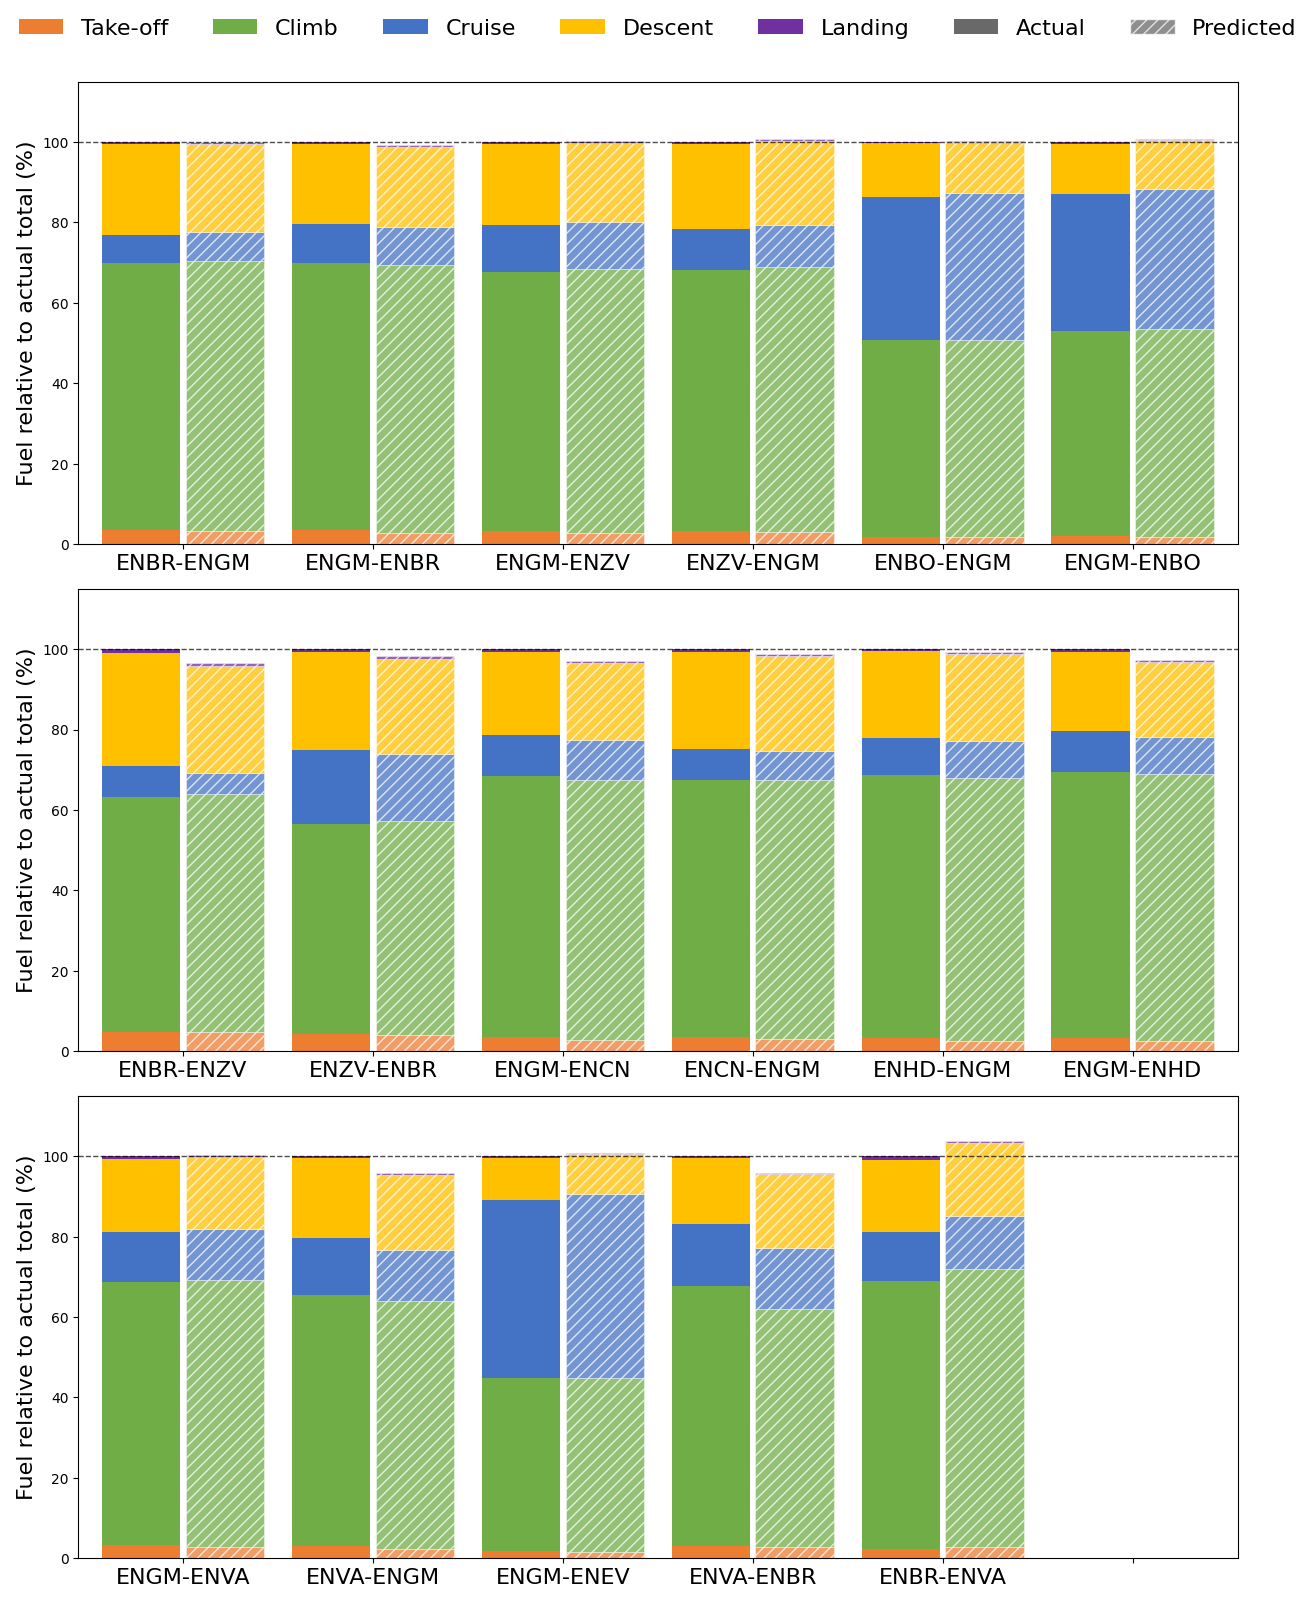

In [7]:
from matplotlib.patches import Patch

phase_colors = {
    "takeoff": "#ED7D31",
    "climb":   "#70AD47",
    "cruise":  "#4472C4",
    "descent": "#FFC000",
    "landing": "#7030A0",
}

routes_per_row = 6
n_rows = int(np.ceil(len(route_phase_percent) / routes_per_row))
bar_width = 0.6
pair_gap  = 0.02

fig, axes = plt.subplots(n_rows, 1, figsize=(14, 5.3 * n_rows))
axes = np.atleast_1d(axes)

for row_idx, ax in enumerate(axes):
    start = row_idx * routes_per_row
    stop  = start + routes_per_row
    plot_routes = route_phase_percent.iloc[start:stop].copy()
    n_in_row = len(plot_routes)

    route_centers = np.arange(routes_per_row) * 1.45
    x_actual = route_centers - bar_width / 2 - pair_gap
    x_pred   = route_centers + bar_width / 2 + pair_gap

    bottom_actual = np.zeros(routes_per_row)
    bottom_pred   = np.zeros(routes_per_row)

    for phase in PHASES:
        actual_values = np.zeros(routes_per_row)
        pred_values   = np.zeros(routes_per_row)

        actual_values[:n_in_row] = plot_routes[f"actual_pct_{phase}"].to_numpy(float)
        pred_values[:n_in_row]   = plot_routes[f"pred_vs_actual_pct_{phase}"].to_numpy(float)

        ax.bar(x_actual, actual_values, width=bar_width,
               bottom=bottom_actual, color=phase_colors[phase])
        ax.bar(x_pred, pred_values, width=bar_width,
               bottom=bottom_pred, color=phase_colors[phase],
               alpha=0.75, hatch="///", edgecolor="white", linewidth=0.4)

        bottom_actual += actual_values
        bottom_pred   += pred_values

    ax.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.7)

    plot_labels = []
    for i in range(routes_per_row):
        if i < n_in_row:
            r = plot_routes.iloc[i]
            plot_labels.append(f"{r.route}")
        else:
            plot_labels.append("")

    ax.set_xticks(route_centers)
    ax.set_xticklabels(plot_labels, ha="center", fontsize=16)
    ax.set_ylabel("Fuel relative to actual total (%)", fontsize=16)
    ax.set_ylim(0, max(115, float(np.nanmax(bottom_pred)) + 8))
    ax.set_xlim(-0.8, routes_per_row * 1.45 - 0.65)

phase_handles = [
    Patch(facecolor=phase_colors[p], label=phase_names[p]) for p in PHASES
]
style_handles = [
    Patch(facecolor="dimgray", label="Actual"),
    Patch(facecolor="dimgray", alpha=0.75, hatch="///",
          edgecolor="white", label="Predicted"),
]
axes[0].legend(
    handles=phase_handles + style_handles,
    ncol=len(PHASES) + 2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    fontsize=16,
    frameon=False,
)

fig.tight_layout()
out_path = os.path.join("../../outputs", "stacked_bars_config2.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
